In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import time
from IPython.display import clear_output, display, HTML
import re
from collections import defaultdict


In [2]:
# Function to extract actor type from actor name
def extract_actor_type(actor):
    match = re.match(r'([a-zA-Z]+)', actor)
    if match:
        return match.group(1)
    return None

In [3]:

# Function to update plots
def update_plots(csv_path):
    import base64
    import io
    
    time_series_data = {}
    
    # Read the CSV file
    df = pd.read_csv(csv_path, names=['timestamp', 'actor', 'metric', 'value'])
    mask = df['actor'].str.contains('Agent')

    new_metric = 'Request(' + df.loc[mask, 'metric'].str.split('Request').str[0] + ')'
    df.loc[mask, 'actor'], df.loc[mask, 'metric'] = new_metric, df.loc[mask, 'actor']
    
    # Extract actor types
    df['actor_type'] = df['actor'].apply(extract_actor_type)
    
    # Update time series data
    for _, row in df.iterrows():
        key = (row['actor_type'], row['metric'], row['actor'])
        if key not in time_series_data:
            time_series_data[key] = []
        
        # Check if this timestamp already exists to avoid duplicates
        timestamp_exists = False
        for existing_timestamp, _ in time_series_data[key]:
            if existing_timestamp == row['timestamp']:
                timestamp_exists = True
                break
        
        if not timestamp_exists:
            time_series_data[key].append((row['timestamp'], row['value']))
    
    # Get unique actor type and metric combinations
    actor_type_metrics = set()
    for (actor_type, metric, _) in time_series_data.keys():
        actor_type_metrics.add((actor_type, metric))
    
    # Calculate grid dimensions
    num_plots = len(actor_type_metrics)
    cols = min(5, num_plots)
    rows = (num_plots + cols - 1) // cols
    
    # Create figure
    fig, axs = plt.subplots(rows, cols, figsize=(30, 5 * rows), sharex=True)

    axs = axs.ravel()
    
    # Sort for consistent plot positions
    for i, (actor_type, metric) in enumerate(sorted(actor_type_metrics)):
        ax = axs[i]
        
        # Find all actors of this type with this metric
        actors = set()
        for key in time_series_data.keys():
            if key[0] == actor_type and key[1] == metric:
                actors.add(key[2])
                
        all_values = []
        # Plot each actor's data
        for actor in sorted(actors):
            key = (actor_type, metric, actor)
            if key in time_series_data and time_series_data[key]:
                timestamps, values = zip(*sorted(time_series_data[key]))
                all_values.extend(values)
                ax.plot(timestamps, values, marker='o', label=actor)
        
        # Set title and labels
        ax.set_title(f"{actor_type} - {metric}")
        ax.set_xlabel("Timestamp")
        ax.set_ylabel("Value")
        ax.legend(loc='lower left')
        ax.grid(True)

        # Apply special y-axis scaling based on metric name and values
        if all_values:
            if "_frac" in metric:
                # For fraction metrics, use a range from -0.02 to 1.02
                ax.set_ylim(-0.02, 1.02)
                min_val = min(all_values)
                max_val = max(all_values)

                adjusted_min = min(0.85, min_val) - 1e-2
                adjusted_max = max(0.15, max_val) + 1e-2
                
            else:
                # For other metrics, ensure the min is at least 30% lower than max
                min_val = min(all_values)
                max_val = max(all_values)
                
                adjusted_min = min(max_val / 2, min_val * 0.8) * .98 - 1e-2
                
                adjusted_max = max_val * 1.02 + 1e-2
            ax.set_ylim(adjusted_min, adjusted_max)
    
    plt.tight_layout()
    #plt.show()

   # Save figure to buffer
    buf = io.BytesIO()
    plt.savefig(buf, format='png')
    buf.seek(0)
    
    data = base64.b64encode(buf.getbuffer()).decode("ascii")
    img_html = f'<img src="data:image/png;base64,{data}">'
    return HTML(img_html)


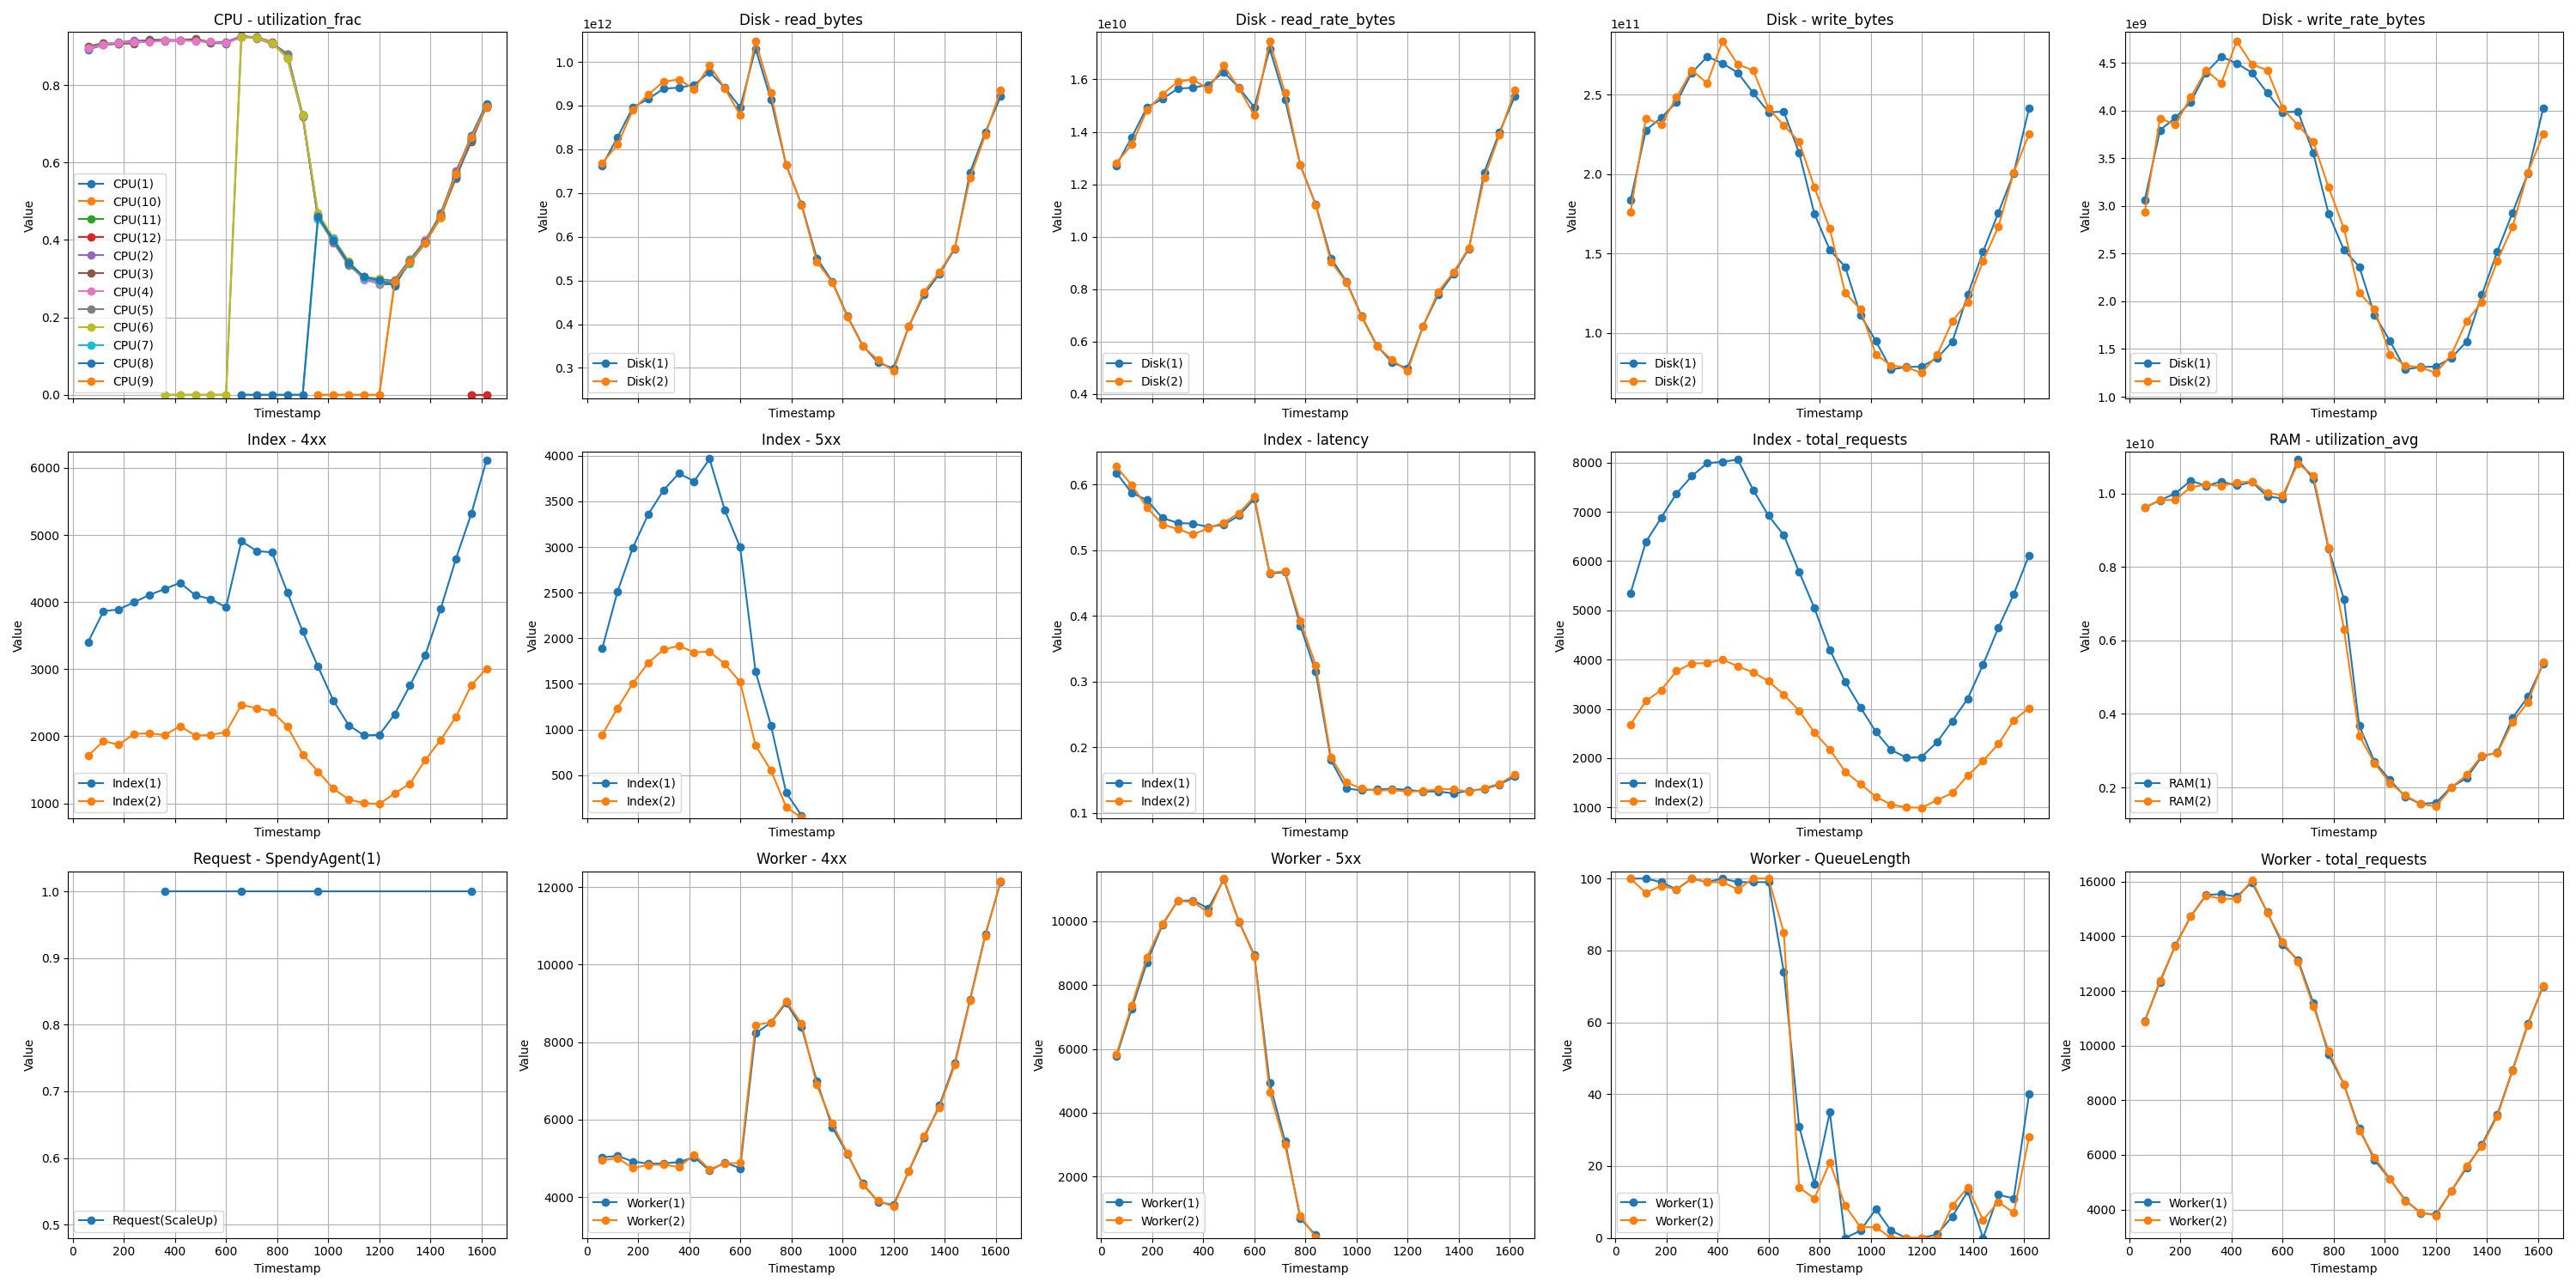

In [ ]:

# Main loop to update every second
while True:
    try:
        plot = update_plots('/tmp/metrics.csv')  # Replace with your CSV file path
        clear_output(wait=True)
        display(plot)
        time.sleep(1)
    except ZeroDivisionError as e:
        time.sleep(1)
        print(e)
        continue
    except (KeyboardInterrupt, ZeroDivisionError):
        break
    except Exception as e:
        raise e